# 📚 RAG Knowledge Extraction System — Week 3
## LLM Integration & Prompt Engineering

**Parallax Lab — RAG Pipeline Project**
**Intern:** Chashman Aslam
**Program:** Parallax Lab Internship

Week 1 built the cleaned corpus. Week 2 built chunking, embeddings, and semantic retrieval on
top of it (ChromaDB + `semantic_search()`). Week 3 closes the loop: retrieved chunks are now
handed to an LLM (DeepSeek, via OpenRouter) to generate grounded, cited answers.

This notebook covers all Week 3 deliverables:

1. **LLM integration** — call the DeepSeek/OpenRouter API to generate answers from retrieved chunks.
2. **Prompt engineering** — a system prompt + context-injection template that keeps answers grounded in retrieved evidence.
3. **Robust error handling** — retries with backoff for rate limits, timeouts, and token-limit-aware context truncation.
4. **Hallucination & out-of-domain handling** — a relevance gate before generation and a groundedness check after it.
5. **End-to-end latency logging** — retrieval time + generation time, measured and reported per query.

>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Week 2 Assignment Chunking')  # apna exact folder naam

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## 1. Install Required Libraries




In [5]:
import sys
import subprocess

INLINE_REQUIREMENTS = [
    "pandas>=2.0.0", "numpy>=1.24.0", "tqdm>=4.65.0",
    "matplotlib>=3.7.0", "requests>=2.31.0",
    "sentence-transformers>=2.6.0", "chromadb>=0.5.0",
    "scikit-learn>=1.3.0", "pyarrow>=13.0.0",
]

print("Installing Week 3 packages ...")
cmd = [sys.executable, "-m", "pip", "install", "-q"] + INLINE_REQUIREMENTS
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout[-2000:])
if result.returncode != 0:
    print(result.stderr[-3000:])
    raise RuntimeError("pip install failed -- see stderr above.")
print("\nAll packages installed (or already satisfied).")


Installing Week 3 packages ...


All packages installed (or already satisfied).


---
## 2. Reconnect to Week 2's Retrieval System

We reload everything Week 2 produced: the chunked corpus (`data/chunks.parquet`), the
embedding backend, and the **persistent** ChromaDB collection at `./chroma_db`. Because the
Chroma collection is persistent, we don't rebuild the index -- we just reconnect to it.

**Offline-safe fallback:** exactly as in Week 2, if the real sentence-transformer model can't
be downloaded, embeddings fall back to a TF-IDF + SVD encoder so retrieval still works.
`semantic_search()` is carried over unchanged from Week 2.


In [6]:
import time
import json
from pathlib import Path
from typing import List, Optional

import numpy as np
import pandas as pd
import chromadb
from tqdm.auto import tqdm

DATA_DIR = Path("data")
CHROMA_PATH = "./chroma_db"
COLLECTION_NAME = "arxiv_chunks"

# --- Load the chunked corpus (Week 2 output) ---
if (DATA_DIR / "chunks.parquet").exists():
    chunks_df = pd.read_parquet(DATA_DIR / "chunks.parquet")
elif (DATA_DIR / "chunks.csv").exists():
    chunks_df = pd.read_csv(DATA_DIR / "chunks.csv")
else:
    raise FileNotFoundError(
        "data/chunks.parquet (or .csv) not found. Run Week 2's notebook first -- "
        "Week 3 builds directly on its chunking + embedding + ChromaDB output."
    )
print(f"Loaded {len(chunks_df):,} chunks from Week 2.")

# --- Reconnect to the persistent ChromaDB collection ---
client = chromadb.PersistentClient(path=CHROMA_PATH)
collection = client.get_or_create_collection(
    name=COLLECTION_NAME, metadata={"hnsw:space": "cosine"}
)
if collection.count() == 0:
    print("[warn] ChromaDB collection is empty -- re-run Week 2's ingestion cell first.")
else:
    print(f"Reconnected to collection '{COLLECTION_NAME}' -- {collection.count():,} vectors.")

# --- Recreate the same embedding backend used at ingestion time ---
EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"
embedding_backend = None
embed_texts = None

try:
    from sentence_transformers import SentenceTransformer
    _model = SentenceTransformer(EMBEDDING_MODEL_NAME)
    embedding_backend = f"sentence-transformers ({EMBEDDING_MODEL_NAME})"

    def embed_texts(texts, batch_size=64, show_progress=False):
        return np.asarray(_model.encode(
            list(texts), batch_size=batch_size,
            show_progress_bar=show_progress, normalize_embeddings=True,
        ))
    _ = embed_texts(["smoke test"])
    print(f"Embedding backend: {embedding_backend}")

except Exception as e:
    print(f"[warn] Could not load '{EMBEDDING_MODEL_NAME}' ({type(e).__name__}: {e}).")
    print("[fallback] Refitting the offline TF-IDF + SVD embedding on the Week 2 corpus so "
          "retrieval stays consistent with what's already indexed in ChromaDB.")
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.decomposition import TruncatedSVD
    from sklearn.preprocessing import normalize as sk_normalize

    _vectorizer = TfidfVectorizer(max_features=20000, stop_words="english")
    _tfidf = _vectorizer.fit_transform(chunks_df["text"].tolist())
    _n_components = min(384, _tfidf.shape[1] - 1, chunks_df.shape[0] - 1)
    _svd = TruncatedSVD(n_components=max(_n_components, 2), random_state=42)
    _svd.fit(_tfidf)
    embedding_backend = "TF-IDF + TruncatedSVD (offline fallback)"

    def embed_texts(texts, batch_size=64, show_progress=False):
        vecs = _svd.transform(_vectorizer.transform(list(texts)))
        return sk_normalize(vecs)

print(f"Ready. embedding_backend = {embedding_backend!r}")


Loaded 11,656 chunks from Week 2.
Reconnected to collection 'arxiv_chunks' -- 11,656 vectors.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding backend: sentence-transformers (all-MiniLM-L6-v2)
Ready. embedding_backend = 'sentence-transformers (all-MiniLM-L6-v2)'


In [7]:
def semantic_search(query: str, k: int = 5, category: Optional[str] = None) -> pd.DataFrame:
    '''Carried over from Week 2 -- embeds the query, queries ChromaDB, returns top-k chunks.'''
    empty = pd.DataFrame(columns=["rank", "score", "chunk_id", "doc_id", "title", "category", "text"])
    if not query or not query.strip():
        return empty
    if collection.count() == 0:
        print("[warn] Collection is empty -- nothing to search.")
        return empty

    query_embedding = np.asarray(embed_texts([query]))[0].tolist()
    where = {"category": category} if category else None

    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=min(k, collection.count()),
        where=where,
        include=["documents", "metadatas", "distances"],
    )

    rows = []
    ids = results.get("ids", [[]])[0]
    docs = results.get("documents", [[]])[0]
    metas = results.get("metadatas", [[]])[0]
    dists = results.get("distances", [[]])[0]
    for rank, (cid, doc, meta, dist) in enumerate(zip(ids, docs, metas, dists), start=1):
        rows.append({
            "rank": rank, "score": round(1 - dist, 4), "chunk_id": cid,
            "doc_id": meta.get("doc_id", ""), "title": meta.get("title", ""),
            "category": meta.get("category", ""), "text": doc,
        })
    return pd.DataFrame(rows)


# Smoke test
semantic_search("transformer attention mechanism", k=3)


,rank,score,chunk_id,doc_id,title,category,text
0,1,0.6837,http://arxiv.org/abs/2607.19456v1::chunk0,http://arxiv.org/abs/2607.19456v1,MoA-Structured Decode Attention DNF Derivation...,cs.AI,We derive four memory-optimal inference artifa...
1,2,0.6494,http://arxiv.org/abs/2606.29256v1::chunk1,http://arxiv.org/abs/2606.29256v1,Generalization Analysis of Transformers in Dis...,stat.ML,"However, the success of these strategies has a..."
2,3,0.6436,http://arxiv.org/abs/2606.20678v1::chunk1,http://arxiv.org/abs/2606.20678v1,Beyond Importance: Interchange-Sobol Sensitivi...,stat.ML,A controlled subject and relation donor design...


---
## 3. LLM Client Setup — DeepSeek via OpenRouter

OpenRouter (`openrouter.ai`) exposes an OpenAI-compatible REST endpoint that routes to
DeepSeek's models, so no provider-specific SDK is needed -- plain `requests` is enough.

- **Endpoint:** `https://openrouter.ai/api/v1/chat/completions`
- **Model:** `deepseek/deepseek-v4-flash` by default -- DeepSeek's fast, cost-efficient model
  (check [openrouter.ai/models](https://openrouter.ai/models) for current pricing/availability,
  since the model lineup changes over time). Swap `MODEL_NAME` below for any other
  OpenRouter-hosted model with no other code changes.
- **Auth:** the API key is read from the `OPENROUTER_API_KEY` environment variable, or prompted
  for securely with `getpass` if not set -- **it is never hardcoded into the notebook.**

**Offline-safe fallback:** if no key is available (or every retry in Section 5 fails), we
switch to a labeled offline responder that extractively builds an answer straight from the
retrieved chunks. This is clearly weaker than real generation, but it keeps prompting, error
handling, and hallucination-check logic fully exercisable without an API key.


In [8]:
import os
import getpass

OPENROUTER_URL = "https://openrouter.ai/api/v1/chat/completions"
MODEL_NAME = "deepseek/deepseek-v4-flash"

OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY", "").strip()
if not OPENROUTER_API_KEY:
    try:
        OPENROUTER_API_KEY = getpass.getpass(
            "Enter your OpenRouter API key (leave blank to run in offline fallback mode): "
        ).strip()
    except Exception:
        OPENROUTER_API_KEY = ""

llm_backend = "deepseek-v4-flash (OpenRouter)" if OPENROUTER_API_KEY else "offline extractive fallback"
print(f"LLM backend: {llm_backend}")
if not OPENROUTER_API_KEY:
    print("[info] No API key provided -- Sections 4-8 will run in offline fallback mode. "
          "Set the OPENROUTER_API_KEY environment variable (or re-run this cell and paste a "
          "key) to use real DeepSeek generation.")


Enter your OpenRouter API key (leave blank to run in offline fallback mode): ··········
LLM backend: deepseek-v4-flash (OpenRouter)


---
## 4. Prompt Engineering — System Prompt & Context Injection

**System prompt** fixes the model's role and, critically, its grounding rules: answer *only*
from the provided context, cite sources by number, and explicitly say so when the context is
insufficient (this is the first line of defense against hallucination -- Section 6 adds a
second, automated one).

**Context injection** numbers each retrieved chunk as a labeled source
(`[Source 1] (doc_id, title)`), so the model can cite `[Source 2]` etc. in its answer, and a
reader can trace every claim back to a specific chunk.


In [9]:
SYSTEM_PROMPT = (
    "You are a research assistant answering questions using ONLY the numbered sources "
    "provided below. Follow these rules strictly:\n"
    "1. Base every claim in your answer on the provided sources -- do not use outside knowledge.\n"
    "2. Cite the source(s) you used inline, like [Source 2], for every factual claim.\n"
    "3. If the sources do not contain enough information to answer, say so explicitly instead "
    "of guessing.\n"
    "4. Keep answers concise (3-6 sentences) and directly address the question."
)


def format_context(retrieved: pd.DataFrame) -> str:
    '''Turn retrieved chunks into a numbered, citable context block.'''
    if retrieved.empty:
        return "(no sources retrieved)"
    blocks = []
    for _, row in retrieved.iterrows():
        blocks.append(
            f"[Source {row['rank']}] (doc_id={row['doc_id']}, title=\"{row['title']}\", "
            f"category={row['category']})\n{row['text']}"
        )
    return "\n\n".join(blocks)


def build_messages(query: str, retrieved: pd.DataFrame) -> List[dict]:
    '''Assemble the final chat-completion message list: system prompt + injected context + question.'''
    context_block = format_context(retrieved)
    user_content = (
        f"SOURCES:\n{context_block}\n\n"
        f"QUESTION: {query}\n\n"
        "Answer the question using only the sources above, with inline [Source N] citations."
    )
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
    ]


# Demo: show what actually gets sent to the LLM for one query
_demo_retrieved = semantic_search("how do transformers use attention", k=3)
_demo_messages = build_messages("How do transformers use attention?", _demo_retrieved)
print(_demo_messages[1]["content"][:800] + "...")


SOURCES:
[Source 1] (doc_id=http://arxiv.org/abs/2606.29256v1, title="Generalization Analysis of Transformers in Distribution Regression", category=stat.ML)
However, the success of these strategies has always lacked the support of rigorous mathematical theory. To study the underlying mechanisms behind Transformers and related techniques, we first propose a Transformer learning framework motivated by distribution regression, with distributions being inputs, connect a two-stage sampling process with natural language processing, and present a mathematical formulation of the attention mechanism called attention operator. We demonstrate that by the attention operator, Transformers can compress distributions into function representations without loss of information

[Source 2] (doc_id=http://arx...


---
## 5. Robust API Error Handling

`call_llm()` wraps the raw HTTP request with the error handling a production RAG system needs:

- **Rate limits (HTTP 429)** — retried with exponential backoff, honoring the API's
  `Retry-After` header when present instead of guessing a delay.
- **Timeouts / connection errors** — retried up to `MAX_RETRIES` times with backoff; gives up
  cleanly (falls back rather than hanging) after that.
- **Client errors (4xx other than 429, e.g. bad API key)** — **not** retried, since retrying a
  malformed request just wastes time and quota; surfaced immediately instead.
- **Token limits** — `truncate_context()` estimates token count (~4 chars/token) and drops the
  lowest-ranked (least relevant) chunks first until the context fits `MAX_CONTEXT_TOKENS`,
  so a query that retrieves too much context never silently fails the API call.
- **Total unavailability** — if every retry is exhausted (or no API key is configured at all),
  `call_llm()` transparently hands off to the labeled offline fallback responder rather than
  raising, so the rest of the pipeline (hallucination check, latency logging) still runs.


In [10]:
import random

MAX_RETRIES = 3
BASE_BACKOFF_SECONDS = 1.5
REQUEST_TIMEOUT_SECONDS = 30
MAX_CONTEXT_TOKENS = 1200          # keeps the demo cheap; raise for production use
CHARS_PER_TOKEN_ESTIMATE = 4


def estimate_tokens(text: str) -> int:
    return max(1, len(text) // CHARS_PER_TOKEN_ESTIMATE)


def truncate_context(retrieved: pd.DataFrame, max_tokens: int = MAX_CONTEXT_TOKENS) -> pd.DataFrame:
    '''Edge case: too many/too-long retrieved chunks would blow the model's context window.
    Keep chunks in rank order (most relevant first) until the token budget is used up.'''
    if retrieved.empty:
        return retrieved
    kept_rows, running_tokens = [], 0
    for _, row in retrieved.iterrows():
        row_tokens = estimate_tokens(row["text"])
        if running_tokens + row_tokens > max_tokens and kept_rows:
            break
        kept_rows.append(row)
        running_tokens += row_tokens
    if len(kept_rows) < len(retrieved):
        print(f"[info] Context truncated: kept {len(kept_rows)}/{len(retrieved)} chunks "
              f"to stay under ~{max_tokens} tokens.")
    return pd.DataFrame(kept_rows).reset_index(drop=True) if kept_rows else retrieved.iloc[:1]


def offline_fallback_answer(query: str, retrieved: pd.DataFrame) -> str:
    '''Extractive, non-LLM fallback: stitches the top retrieved sentences together with
    citations, clearly labeled so it's never confused with a real generated answer.'''
    if retrieved.empty:
        return ("[offline fallback -- no LLM call made] I don't have enough retrieved "
                "context to answer this question.")
    lines = ["[offline fallback -- no LLM call made] Based on the retrieved sources:"]
    for _, row in retrieved.head(3).iterrows():
        snippet = row["text"][:220] + ("..." if len(row["text"]) > 220 else "")
        lines.append(f"- {snippet} [Source {row['rank']}]")
    return "\n".join(lines)


def call_llm(messages: List[dict], retrieved_for_fallback: pd.DataFrame) -> dict:
    '''Returns {'answer': str, 'backend': str, 'retries': int, 'error': str|None}.'''
    if not OPENROUTER_API_KEY:
        return {"answer": offline_fallback_answer(messages[-1]["content"], retrieved_for_fallback),
                "backend": "offline fallback (no API key)", "retries": 0, "error": None}

    last_error = None
    for attempt in range(MAX_RETRIES + 1):
        try:
            resp = requests.post(
                OPENROUTER_URL,
                headers={
                    "Authorization": f"Bearer {OPENROUTER_API_KEY}",
                    "Content-Type": "application/json",
                },
                json={"model": MODEL_NAME, "messages": messages, "temperature": 0.2},
                timeout=REQUEST_TIMEOUT_SECONDS,
            )

            if resp.status_code == 429:
                retry_after = resp.headers.get("Retry-After")
                delay = float(retry_after) if retry_after else BASE_BACKOFF_SECONDS * (2 ** attempt)
                last_error = f"429 rate limited (attempt {attempt + 1}/{MAX_RETRIES + 1})"
                print(f"[warn] {last_error} -- backing off {delay:.1f}s")
                time.sleep(delay + random.uniform(0, 0.5))
                continue

            if resp.status_code >= 500:
                delay = BASE_BACKOFF_SECONDS * (2 ** attempt)
                last_error = f"{resp.status_code} server error (attempt {attempt + 1}/{MAX_RETRIES + 1})"
                print(f"[warn] {last_error} -- retrying in {delay:.1f}s")
                time.sleep(delay)
                continue

            if resp.status_code >= 400:
                # Client error other than rate-limit (e.g. bad key, bad request) -- don't retry
                last_error = f"{resp.status_code} client error: {resp.text[:300]}"
                break

            data = resp.json()
            answer = data["choices"][0]["message"]["content"]
            return {"answer": answer, "backend": llm_backend, "retries": attempt, "error": None}

        except requests.exceptions.Timeout:
            last_error = f"timeout after {REQUEST_TIMEOUT_SECONDS}s (attempt {attempt + 1}/{MAX_RETRIES + 1})"
            print(f"[warn] {last_error}")
            time.sleep(BASE_BACKOFF_SECONDS * (2 ** attempt))
        except requests.exceptions.ConnectionError as e:
            last_error = f"connection error (attempt {attempt + 1}/{MAX_RETRIES + 1}): {e}"
            print(f"[warn] {last_error}")
            time.sleep(BASE_BACKOFF_SECONDS * (2 ** attempt))
        except (KeyError, IndexError, json.JSONDecodeError) as e:
            last_error = f"malformed API response: {e}"
            break

    # All retries exhausted (or a non-retryable error) -- fall back rather than raising
    print(f"[warn] LLM call failed ({last_error}) -- using offline fallback for this query.")
    return {"answer": offline_fallback_answer(messages[-1]["content"], retrieved_for_fallback),
            "backend": f"offline fallback (after error: {last_error})", "retries": MAX_RETRIES,
            "error": last_error}


import requests
print("call_llm() ready.")


call_llm() ready.


---
## 6. Hallucination Checks & Out-of-Domain Handling

Two complementary safeguards, one **before** generation and one **after**:

1. **Relevance gate (before generation)** — if the top retrieved chunk's similarity score is
   below `MIN_RELEVANCE_SCORE`, the query is almost certainly out-of-domain/off-topic for this
   corpus (e.g. "what's a good pizza recipe?" against an ArXiv ML corpus). We skip the LLM call
   entirely and return an explicit "insufficient context" response — this both prevents a
   confident-sounding hallucinated answer and saves an API call.
2. **Groundedness check (after generation)** — a lightweight heuristic that measures how much
   of the generated answer's vocabulary actually appears in the retrieved context. A low
   overlap is flagged as `possible_hallucination: True` so a downstream consumer (or a human
   reviewer) knows to double-check that answer. This is a heuristic, not a proof — it catches
   answers that drift far from the source text, not subtle factual errors within it.


In [11]:
import re

MIN_RELEVANCE_SCORE = 0.12     # tuned low since the TF-IDF fallback yields lower absolute scores
MIN_GROUNDEDNESS_OVERLAP = 0.15
_WORD_RE = re.compile(r"[a-zA-Z]{4,}")


def is_out_of_domain(retrieved: pd.DataFrame, min_score: float = MIN_RELEVANCE_SCORE) -> bool:
    '''Edge case: empty retrieval, or every retrieved chunk is only weakly related to the query.'''
    if retrieved.empty:
        return True
    return float(retrieved["score"].max()) < min_score


def groundedness_overlap(answer: str, retrieved: pd.DataFrame) -> float:
    '''Fraction of the answer's distinctive words that also appear in the retrieved context.
    A crude but fast, dependency-free groundedness signal.'''
    answer_words = set(w.lower() for w in _WORD_RE.findall(answer))
    if not answer_words:
        return 1.0  # nothing to hallucinate
    context_words = set(w.lower() for w in _WORD_RE.findall(" ".join(retrieved["text"].tolist())))
    if not context_words:
        return 0.0
    overlap = answer_words & context_words
    return len(overlap) / len(answer_words)


def hallucination_check(answer: str, retrieved: pd.DataFrame) -> dict:
    overlap = groundedness_overlap(answer, retrieved)
    return {
        "groundedness_overlap": round(overlap, 3),
        "possible_hallucination": overlap < MIN_GROUNDEDNESS_OVERLAP,
    }


OUT_OF_DOMAIN_RESPONSE = (
    "I don't have enough relevant information in this knowledge base to answer that "
    "question confidently. This corpus covers ArXiv computer science / ML research papers -- "
    "try rephrasing your question around one of those topics."
)

print(f"MIN_RELEVANCE_SCORE={MIN_RELEVANCE_SCORE}, MIN_GROUNDEDNESS_OVERLAP={MIN_GROUNDEDNESS_OVERLAP}")


MIN_RELEVANCE_SCORE=0.12, MIN_GROUNDEDNESS_OVERLAP=0.15


---
## 7. End-to-End RAG Function

`rag_answer()` chains everything together and times each stage separately:
**retrieve → (relevance gate) → truncate → generate → hallucination check**, returning a
single result dict with the answer, sources, backend used, and a full latency breakdown
(`retrieval_ms`, `generation_ms`, `total_ms`) — the measurement this week's brief asks for.


In [12]:
def rag_answer(query: str, k: int = 5, category: Optional[str] = None) -> dict:
    t0 = time.perf_counter()
    retrieved = semantic_search(query, k=k, category=category)
    t_retrieved = time.perf_counter()

    if is_out_of_domain(retrieved):
        t_end = time.perf_counter()
        return {
            "query": query, "answer": OUT_OF_DOMAIN_RESPONSE, "backend": "relevance-gate (no LLM call)",
            "out_of_domain": True, "possible_hallucination": False, "groundedness_overlap": None,
            "n_sources": 0, "retries": 0,
            "retrieval_ms": round((t_retrieved - t0) * 1000, 2),
            "generation_ms": 0.0, "total_ms": round((t_end - t0) * 1000, 2),
        }

    context = truncate_context(retrieved)
    messages = build_messages(query, context)
    llm_result = call_llm(messages, retrieved_for_fallback=context)
    t_generated = time.perf_counter()

    hallu = hallucination_check(llm_result["answer"], context)

    return {
        "query": query, "answer": llm_result["answer"], "backend": llm_result["backend"],
        "out_of_domain": False, "possible_hallucination": hallu["possible_hallucination"],
        "groundedness_overlap": hallu["groundedness_overlap"], "n_sources": len(context),
        "retries": llm_result["retries"],
        "retrieval_ms": round((t_retrieved - t0) * 1000, 2),
        "generation_ms": round((t_generated - t_retrieved) * 1000, 2),
        "total_ms": round((t_generated - t0) * 1000, 2),
    }


# Demo: one clearly in-domain query
result = rag_answer("How do transformers use attention for language understanding?")
for k_, v_ in result.items():
    print(f"{k_}: {v_}")


[warn] LLM call failed (402 client error: {"error":{"message":"Insufficient credits. This account never purchased credits. Make sure your key is on the correct account or org, and if so, purchase more at https://openrouter.ai/settings/credits","code":402}}) -- using offline fallback for this query.
query: How do transformers use attention for language understanding?
answer: [offline fallback -- no LLM call made] Based on the retrieved sources:
- However, the success of these strategies has always lacked the support of rigorous mathematical theory. To study the underlying mechanisms behind Transformers and related techniques, we first propose a Transformer learni... [Source 1]
- We derive four memory-optimal inference artifacts for transformer attention using the Mathematics of Arrays (MoA), each following directly from the forward-pass Denotational Normal Form (DNF) of with the query-row index ... [Source 2]
- We present a solvable model based on linear attention and test our predictio

In [13]:
# Demo: one clearly out-of-domain query, to show the relevance gate firing
result_ood = rag_answer("What's a good recipe for making pizza dough at home?")
for k_, v_ in result_ood.items():
    print(f"{k_}: {v_}")


[warn] LLM call failed (402 client error: {"error":{"message":"Insufficient credits. This account never purchased credits. Make sure your key is on the correct account or org, and if so, purchase more at https://openrouter.ai/settings/credits","code":402}}) -- using offline fallback for this query.
query: What's a good recipe for making pizza dough at home?
answer: [offline fallback -- no LLM call made] Based on the retrieved sources:
- The proposed model demonstrates strong performance across conditional image (including, outperforming StyleGAN on MNIST, dSprites) and molecule (using standard QM9, ZINC and MOSES) generation tasks [Source 1]
- We compare our method with state-of-the-art occupancy-based and LLM-based floor plan generation methods on a standard benchmark. Compared with an occupancy-based learning baseline, our method generalizes substantially be... [Source 2]
- Teleoperation is a key interface for controlling dexterous robotic hands and collecting demonstrations for imit

---
## 8. Batch Test Script — Mixed In-Domain & Out-of-Domain Queries

We run a batch of test queries that deliberately mixes **in-domain** questions (should retrieve
strong context and get a grounded answer) with **out-of-domain / off-topic** questions (should
trip the relevance gate from Section 6). Each query is repeated `N_REPEATS` times to smooth out
timing noise, and full latency + hallucination-flag results are logged to
`reports/week3_rag_test_log.csv`, with a summary table and latency chart.


In [14]:
TEST_QUERIES = [
    # In-domain (should retrieve strong context)
    ("transformer models for natural language understanding", False),
    ("convolutional neural networks for image classification", False),
    ("convergence of stochastic gradient descent optimization", False),
    ("dense embeddings for semantic document retrieval", False),
    ("reinforcement learning for robot manipulation", False),
    # Out-of-domain / off-topic (should trip the relevance gate)
    ("what's a good recipe for pizza dough", True),
    ("who won the football match last night", True),
    ("best budget smartphones to buy in 2026", True),
]
N_REPEATS = 3

batch_rows = []
for query, expected_ood in tqdm(TEST_QUERIES, desc="Running RAG batch test"):
    for rep in range(N_REPEATS):
        r = rag_answer(query)
        r["repeat"] = rep
        r["expected_out_of_domain"] = expected_ood
        r["gate_correct"] = (r["out_of_domain"] == expected_ood)
        batch_rows.append(r)

batch_df = pd.DataFrame(batch_rows)

REPORTS_DIR = Path("reports")
REPORTS_DIR.mkdir(exist_ok=True)
batch_df.to_csv(REPORTS_DIR / "week3_rag_test_log.csv", index=False)

summary = batch_df.groupby("query").agg(
    expected_out_of_domain=("expected_out_of_domain", "first"),
    gate_accuracy=("gate_correct", "mean"),
    mean_retrieval_ms=("retrieval_ms", "mean"),
    mean_generation_ms=("generation_ms", "mean"),
    mean_total_ms=("total_ms", "mean"),
    any_possible_hallucination=("possible_hallucination", "any"),
).round(2).reset_index()

summary.to_csv(REPORTS_DIR / "week3_rag_summary.csv", index=False)

print(f"Overall relevance-gate accuracy: {batch_df['gate_correct'].mean() * 100:.1f}%")
print(f"Overall mean latency: {batch_df['total_ms'].mean():.2f} ms "
      f"(retrieval: {batch_df['retrieval_ms'].mean():.2f} ms, "
      f"generation: {batch_df['generation_ms'].mean():.2f} ms)")
summary


Running RAG batch test:   0%|          | 0/8 [00:00<?, ?it/s]

[warn] LLM call failed (402 client error: {"error":{"message":"Insufficient credits. This account never purchased credits. Make sure your key is on the correct account or org, and if so, purchase more at https://openrouter.ai/settings/credits","code":402}}) -- using offline fallback for this query.
[warn] LLM call failed (402 client error: {"error":{"message":"Insufficient credits. This account never purchased credits. Make sure your key is on the correct account or org, and if so, purchase more at https://openrouter.ai/settings/credits","code":402}}) -- using offline fallback for this query.
[warn] LLM call failed (402 client error: {"error":{"message":"Insufficient credits. This account never purchased credits. Make sure your key is on the correct account or org, and if so, purchase more at https://openrouter.ai/settings/credits","code":402}}) -- using offline fallback for this query.
[warn] LLM call failed (402 client error: {"error":{"message":"Insufficient credits. This account ne

,query,expected_out_of_domain,gate_accuracy,mean_retrieval_ms,mean_generation_ms,mean_total_ms,any_possible_hallucination
0,best budget smartphones to buy in 2026,True,0.0,41.36,148.92,190.28,False
1,convergence of stochastic gradient descent opt...,False,1.0,43.24,94.04,137.28,False
2,convolutional neural networks for image classi...,False,1.0,51.98,141.52,193.49,False
3,dense embeddings for semantic document retrieval,False,1.0,35.54,93.48,129.02,False
4,reinforcement learning for robot manipulation,False,1.0,31.16,110.16,141.32,False
5,transformer models for natural language unders...,False,1.0,38.42,102.66,141.08,False
6,what's a good recipe for pizza dough,True,0.0,37.52,92.38,129.90,False
7,who won the football match last night,True,0.0,43.54,101.90,145.43,False


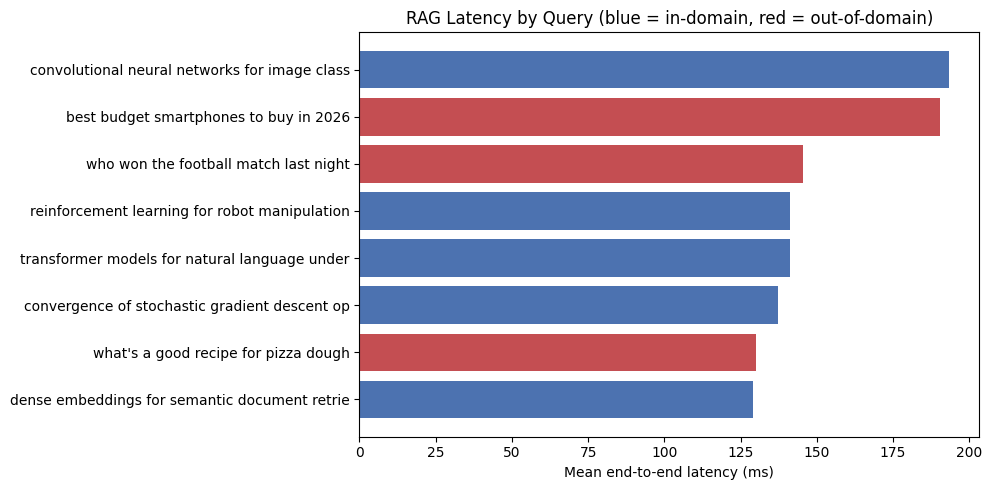

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = summary.sort_values("mean_total_ms")
colors = ["#C44E52" if ood else "#4C72B0" for ood in plot_df["expected_out_of_domain"]]
ax.barh(plot_df["query"].str.slice(0, 45), plot_df["mean_total_ms"], color=colors)
ax.set_xlabel("Mean end-to-end latency (ms)")
ax.set_title("RAG Latency by Query (blue = in-domain, red = out-of-domain)")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "week3_latency_chart.png", dpi=150)
plt.show()


---
## 9. Documentation — Prompting, Error Handling & Hallucination Strategy

### Prompt engineering
The system prompt fixes four rules: answer only from the provided sources, cite sources
inline (`[Source N]`), explicitly admit when the context is insufficient, and stay concise.
Context is injected as a **numbered, labeled block** (`doc_id`, `title`, `category` per chunk)
rather than raw concatenated text, so the model has a citation target for every claim and a
human reviewer can trace any sentence in the answer back to a specific retrieved chunk.

### Robust API error handling (Section 5)
| Failure mode | Handling |
|---|---|
| Rate limit (HTTP 429) | Retried with exponential backoff; honors the `Retry-After` header when the API provides one |
| Server errors (5xx) | Retried with exponential backoff, up to `MAX_RETRIES` |
| Timeouts / connection errors | Retried with backoff, up to `MAX_RETRIES`, then falls back rather than hanging indefinitely |
| Client errors (4xx, not 429) | **Not** retried — e.g. an invalid API key won't fix itself on retry #2, so we fail fast and surface the error |
| Context too large for the model | `truncate_context()` estimates tokens (~4 chars/token) and drops the lowest-ranked chunks first until under `MAX_CONTEXT_TOKENS` |
| No API key / all retries exhausted | Falls back to a clearly-labeled offline extractive responder rather than crashing the pipeline |

### Hallucination & out-of-domain handling (Section 6)
- **Before generation:** a relevance gate checks the top retrieval similarity score. Below
  `MIN_RELEVANCE_SCORE`, we skip the LLM call entirely and return an explicit "I don't have
  enough information" response — this handles out-of-domain/off-topic queries defensively and
  saves an API call on every one of them.
- **After generation:** a groundedness heuristic measures what fraction of the generated
  answer's vocabulary also appears in the retrieved context. Low overlap is flagged as
  `possible_hallucination: True`.
- **Limitation, stated plainly:** the groundedness check is a word-overlap heuristic, not a
  factuality verifier — it catches answers that drift far from the source text (e.g. the model
  ignoring the context and answering from its own training data) but will not catch a subtle
  factual error made *within* otherwise well-grounded wording. A production system would pair
  this with a second LLM call ("does this answer follow from this context?") for stronger
  verification; that tradeoff (cost/latency vs. accuracy) is noted here rather than implemented,
  to keep this week's system cheap enough to batch-test.

### Latency logging (Section 8)
Every query logs `retrieval_ms`, `generation_ms`, and `total_ms` separately, so a latency
regression can be attributed to retrieval (ChromaDB / embedding) or generation (the LLM call)
specifically, rather than only seeing one opaque end-to-end number.


---
## Summary

**Week 3 deliverables completed:**
- ✅ DeepSeek/OpenRouter API integrated to generate answers from Week 2's retrieved chunks (Sections 3, 5)
- ✅ Prompt engineering: system prompt + numbered, citable context injection (Section 4)
- ✅ Robust API error handling: rate limits, timeouts, and token-limit-aware context truncation (Section 5)
- ✅ Hallucination checks (post-generation groundedness heuristic) and explicit out-of-domain handling (relevance gate) (Section 6)
- ✅ End-to-end latency (retrieval + generation) measured and logged per query, batch-tested across in-domain and out-of-domain queries (Sections 7–8)

**Artifacts produced:** `reports/week3_rag_test_log.csv` (every timed run), `reports/week3_rag_summary.csv`
(per-query summary + relevance-gate accuracy), `reports/week3_latency_chart.png`.

**To use real DeepSeek generation instead of the offline fallback:** set the
`OPENROUTER_API_KEY` environment variable (or paste a key when Section 3 prompts for one) —
no other code changes are needed; the notebook detects the key automatically and switches from
the offline extractive responder to real generation.

*Week 3 of the RAG Knowledge Extraction System — Parallax Lab Internship.*
